# Figure 4 — is the anchoring state carried by a wired local network?

Figure 2 found that **grid cells and putative interneurons** follow the
population anchoring state, and follow each other, while other spatial cells do
not. That is an identity result, and it invites a circuit explanation: perhaps
the cells that share a state are the cells that are **synaptically connected**.

This figure tests that directly, and to do so the detector had to be extended
first.

---

## The detector had a multiple-comparison bug

`figure_playground/ccg_monosynaptic_M25D25.ipynb` implements the English et al.
/ Stark & Abeles criteria and finds **zero** connections in 17,366 tested pairs.
That is not biology. Two rejection rules are applied per-bin and uncorrected
across a ±50 ms window holding 101 bins:

| rule | as written | fires by chance on |
|---|---|---|
| R1 | reject if **any** non-peak bin > 2.5 SD | ~45% of pairs |
| R2 | reject if **any** anticausal bin has p < 0.01 | ~39% of pairs |

Together they reject roughly two thirds of *all* pairs regardless of what the
CCG contains. `monosyn.py` gives the rejection rules the same Šidák correction
the detection gets, across the number of bins each rule actually examines.
Everything else is unchanged: 1 ms bins, ±50 ms, hollow-Gaussian predictor
(σ = 5 ms, 60% hollow), the 0.7–4.7 ms causal window, Poisson tests with
continuity correction, minimum spike counts, and the zero-lag exclusion.

## And it could only see excitation

The published criteria look for a short-latency **peak**, so they find
excitatory connections only. Everything an inhibitory cell does to its target
appears as a **trough**, and was invisible *in principle* — which made the
interneuron half of this question unanswerable rather than merely underpowered.

`monosyn.detect(kind='inh')` mirrors every criterion on the **lower** tail of
the same Poisson test, taking the causal extremum as a minimum rather than a
maximum. Nothing else changes, so the two signs are held to identical
thresholds and identical rejection rules, and each gets its own jitter null.

## Loosening a rule cannot validate itself

A higher count is not evidence the fix is right — relaxing a rejection can only
increase it. So the threshold is set from a **jitter null**: the same spikes
displaced by ±10 ms, which destroys millisecond timing while preserving firing
rate, slow co-modulation and the coarse CCG shape. A correct detector finds
essentially nothing there.

On M25 D25 (20,052 pairs tested), sweeping the peak threshold:

| α (peak) | real | null run 1 | null run 2 | FDR |
|---|---|---|---|---|
| 1×10⁻³ | 14 | 3 | 0 | 0.11 |
| **3×10⁻⁴** | **11** | **1** | **0** | **0.05** |
| 1×10⁻⁴ | 8 | 1 | 0 | 0.06 |
| 3×10⁻⁶ | 2 | 1 | 0 | 0.25 |

α = 3×10⁻⁴ is where the null is essentially empty while the real count is still
near its maximum. That is the operating point, and it is set by the null rather
than by convention. Across the whole dataset it holds for both signs:
**FDR 0.09 excitatory, 0.10 inhibitory** (panel H).

Two independent checks that the inhibitory detections are real synapses and not
a mirror-image artefact of the predictor — neither of which the detector could
produce by construction:

- inhibitory latencies are **slower** than excitatory ones (median 3.0 vs
  1.0 ms), the expected sign for a disynaptic-free but slower GABA_A
  conductance (panel C);
- inhibitory connections originate from **waveform-classified interneurons**,
  3.1× over their share of the population, while excitatory ones do not
  (panel D). The waveform classification was never used to find them.


## Why the matching is the whole analysis

Connected pairs are close together **by construction** — a monosynaptic peak is
only detectable between cells the probe records well, which are usually
neighbours. And neighbouring cells share anchoring for reasons that have nothing
to do with being wired: common input, shared local field, and spike-sorting
bleed, which manufactures the connection and the correlation at the same time.

On top of that, Figure 2 has already shown that **identity** predicts anchoring
agreement on its own — two grid cells agree at r ≈ +0.5 whether or not anything
connects them. Since connectivity is itself strongly identity-structured
(panels E, F), an unmatched comparison would recover the identity effect and
report it as a wiring effect.

So every connected pair is compared against unconnected pairs **from the same
session**, of the **same identity pair**, and at a similar probe distance
(±40 µm). Cells whose labels are constant across all trials are excluded: under
the absolute gate about a third of cells are all-anchored or all-non-anchored,
and a constant vector has no correlation with anything.


## Step 1 — detect connections, both signs

Runs `monosyn.py` over every session that has anchoring labels, with a jitter
null in every fourth session. Each pass now tests the causal window against
**both** Poisson tails, writing `connections2_w*.csv` / `cells2_w*.csv`. About
40 minutes for 62 sessions on 3 workers. Cached to `data/monosyn/`, so this is
a no-op once built — delete those files to force a rebuild.


In [1]:
"""Putative monosynaptic connections, both signs, in data/monosyn/."""
import glob, os, subprocess, sys

FIGDIR = ('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
          'AnchorDynamics2026')
MS = '/Users/harryclark/Documents/spatial-manifolds/data/monosyn'
NW = 3

if glob.glob(f'{MS}/connections2_w*.csv'):
    import pandas as pd
    C = pd.concat([pd.read_csv(f) for f in glob.glob(f'{MS}/connections2_w*.csv')])
    K = pd.concat([pd.read_csv(f) for f in glob.glob(f'{MS}/cells2_w*.csv')])
    print(f'cached: {len(C)} connections '
          f'({(C.kind == "exc").sum()} exc, {(C.kind == "inh").sum()} inh) in '
          f'{K.groupby(["mouse", "day"]).ngroups} sessions')
else:
    ps = [subprocess.Popen([sys.executable, f'{FIGDIR}/monosyn.py', 'batch',
                            str(w), str(NW)], cwd=FIGDIR) for w in range(NW)]
    for p in ps:
        assert p.wait() == 0


cached: 8834 connections (1059 exc, 7775 inh) in 60 sessions


## Step 2 — the figure

`fig4_monosyn_anchoring.py`, run from the notebook so the two cannot drift
apart. The pair-level test is cached to `data/monosyn/pairs_by_identity.csv`;
delete it to recompute.

- **A, B** example correlograms of each sign against the hollow-Gaussian
  predictor — an excitatory peak and an inhibitory trough, shaded causal window
- **C** the two populations are physiologically distinct: inhibition is slower
- **D** and come from the right cells — inhibitory connections originate from
  waveform-classified interneurons, which were never used to find them
- **E, F** connection probability between identity groups, per sign, as a
  percentage of the ordered pairs that were actually testable
- **G** **the test** — anchoring-label correlation for connected pairs (filled)
  against identity- and distance-matched unconnected pairs (open)
- **H** detection validated against the ±10 ms jitter null, both signs


8834 connections, 60 sessions: 1059 excitatory, 7775 inhibitory
  jitter null (15 sessions): exc FDR 0.09, inh FDR 0.10


  exc grid -> grid: 13 obs vs 5.0 shuffled (2.58x, p=0.0040)


  inh putative interneuron -> grid: 304 obs vs 60.9 shuffled (4.99x, p=0.0005)
  grid+grid  connected    27 r=+0.5101  control r=+0.4648  p=0.31
  grid+int   connected   194 r=+0.1754  control r=+0.1838  p=0.46


  int+int    connected   119 r=+0.0885  control r=+0.0929  p=0.83


  other      connected  3234 r=+0.0685  control r=+0.0620  p=0.022



saved /Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/fig4_monosyn_anchoring.pdf


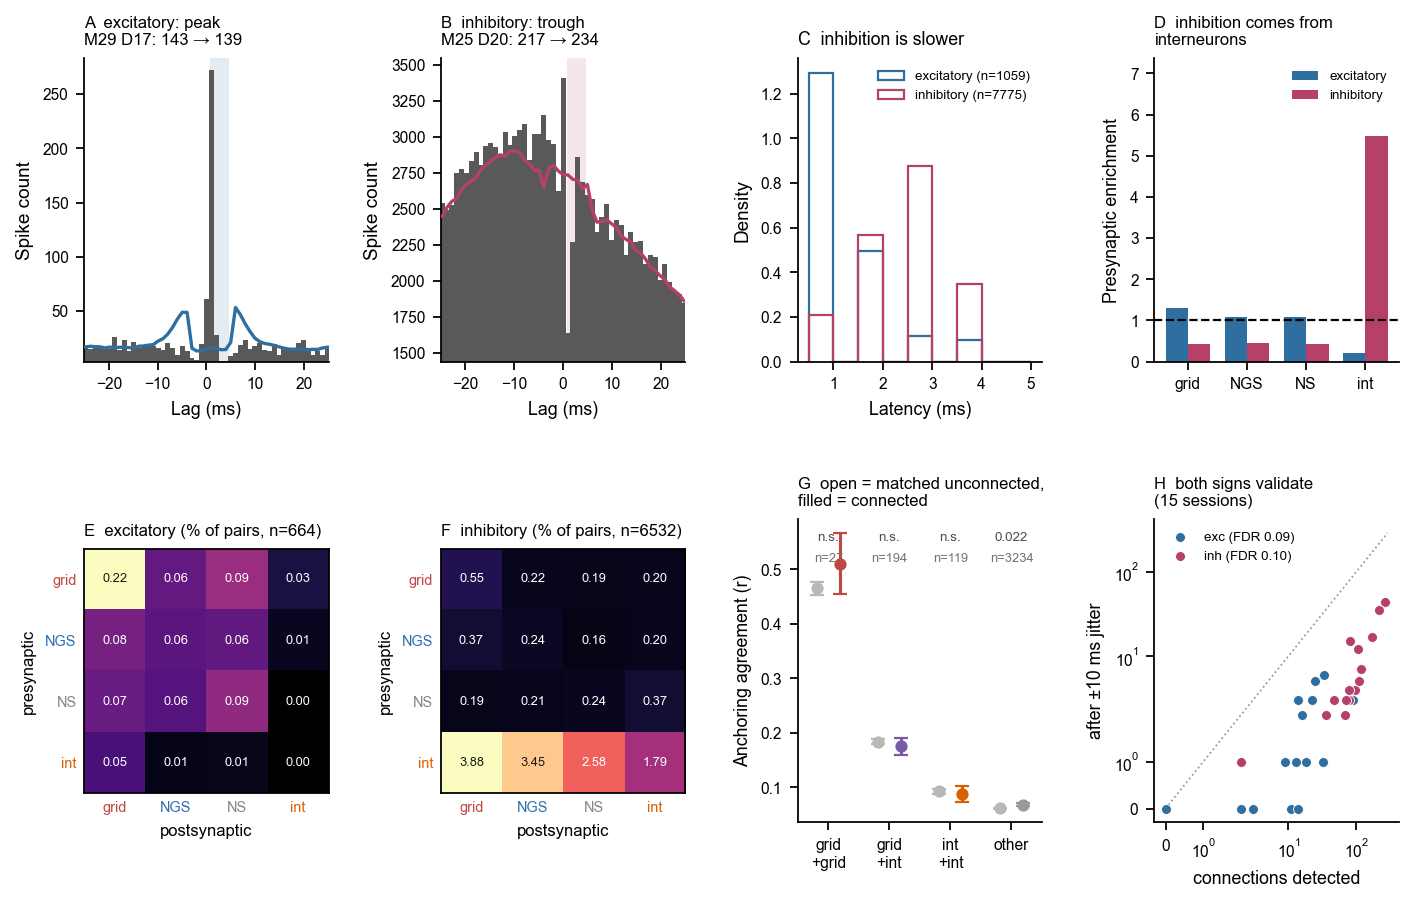

In [2]:
"""Figure 4, built from the script so the notebook cannot drift from it.

`_g` keeps the script namespace:
    _g['C']    all detected connections, both signs
    _g['P']    every usable pair with its anchoring-label correlation
    _g['RES']  per identity-pair: connected r, matched control r, p
"""
import io
import runpy

from IPython.display import Image, display

_g = runpy.run_path(f'{FIGDIR}/fig4_monosyn_anchoring.py', run_name='__main__')

# the script forces the Agg backend, so hand the canvas to IPython directly
# rather than relying on the inline figure formatter
_b = io.BytesIO()
_g['fig'].savefig(_b, format='png', dpi=160, bbox_inches='tight')
display(Image(data=_b.getvalue()))


## What it says

**Connectivity is strongly organised by identity, and in the predicted places.**
`int → grid` is the strongest pathway in either matrix (3.88% of testable
ordered pairs, 5.0× enriched over within-session identity shuffling,
p = 0.0005), and `grid → grid` the strongest excitatory one (0.217%, 2.6×
enriched, p = 0.004). The local network that Figure 2 implied on functional
grounds is there in the spike timing.

**But it does not carry the anchoring state.** Connected pairs do not share the
state more than unconnected pairs matched for identity and probe distance:

| pair | connected | matched control | p |
|---|---|---|---|
| grid + grid | +0.510 (n=27) | +0.465 | 0.31 |
| grid + int | +0.175 (n=194) | +0.184 | 0.46 |
| int + int | +0.089 (n=119) | +0.093 | 0.83 |
| other | +0.069 (n=3234) | +0.062 | 0.022 |

Grid pairs agree at +0.51 whether or not a synapse is detectable between them.
The one significant row is the heterogeneous `other` pool, where the effect is
+0.007 — an order of magnitude smaller than the identity differences down the
left-hand column, and significant only because it pools 3,234 pairs.

So the local network is real and the shared state is real, but **the second is
not explained by the first**. Anchoring travels with cell identity, not with
synaptic partnership — consistent with a state imposed on the whole population
by a common input that grid cells and interneurons are simply more sensitive
to, rather than one propagated cell-to-cell through local wiring.
